<a href="https://colab.research.google.com/github/BeastAkshat123/Celebal-Technology-Data-Science-Assignments/blob/main/Week4_Akshat_Sharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

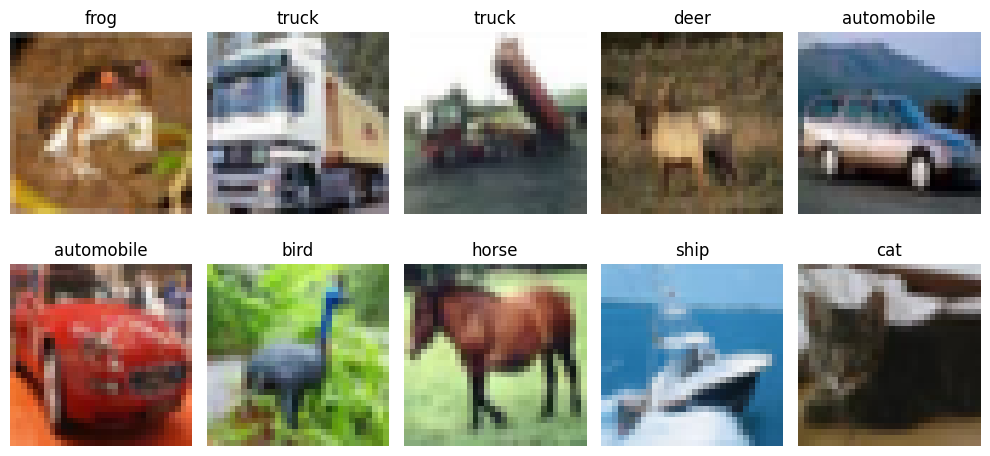

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.1090 - loss: 2.3396
ANN Test Accuracy: 0.10899999737739563


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,874 (2.49 MB)

 Trainable params: 652,426 (2.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.0976 - loss: 2.3036
CNN Test Accuracy: 0.09759999811649323


# Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train ANN (20 Epochs)

In [ ]:
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 92ms/step - accuracy: 0.2112 - loss: 2.1103 - val_accuracy: 0.3004 - val_loss: 1.9691
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 90ms/step - accuracy: 0.2606 - loss: 1.9722 - val_accuracy: 0.3034 - val_loss: 1.9322
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.2790 - loss: 1.9374 - val_accuracy: 0.3132 - val_loss: 1.9143
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.2888 - loss: 1.9123 - val_accuracy: 0.3422 - val_loss: 1.8804
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.2979 - loss: 1.8966 - val_accuracy: 0.3474 - val_loss: 1.8719
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 98ms/step - accuracy: 0.3044 - loss: 1.8864 - val_accuracy: 0.3170 - val_loss: 1.8966
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 94ms/step - accuracy: 0.3093 - loss: 1.8725 - val_accuracy: 0.3504 - val_loss: 1.8729
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 89ms/step - accuracy: 0.3089 - loss: 1.8665 - 

# Train CNN (20 Epochs)

In [ ]:
cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 181s 252ms/step - accuracy: 0.4138 - loss: 1.6439 - val_accuracy: 0.4272 - val_loss: 1.5950
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 250ms/step - accuracy: 0.5823 - loss: 1.1962 - val_accuracy: 0.4638 - val_loss: 1.6168
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 209s 261ms/step - accuracy: 0.6580 - loss: 0.9969 - val_accuracy: 0.6146 - val_loss: 1.0996
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 187s 266ms/step - accuracy: 0.6991 - loss: 0.8727 - val_accuracy: 0.5926 - val_loss: 1.3624
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 185s 263ms/step - accuracy: 0.7325 - loss: 0.7824 - val_accuracy: 0.6868 - val_loss: 0.8964
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 179s 254ms/step - accuracy: 0.7585 - loss: 0.7079 - val_accuracy: 0.6946 - val_loss: 0.8941
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 171s 243ms/step - accuracy: 0.7802 - loss: 0.6420 - val_accuracy: 0.7570 - val_loss: 0.7273
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 175s 249ms/step - accuracy: 0.8027 -

# Evaluate ANN

In [ ]:
ann_loss, ann_acc = ann_model.evaluate(
    x_test_flat,
    y_test
)

print("ANN Test Accuracy:", ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3958 - loss: 1.7375
ANN Test Accuracy: 0.39579999446868896


# Evaluate CNN

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN Test Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7451 - loss: 0.7629
CNN Test Accuracy: 0.7451000213623047


## 📈 Compare Learning Curves

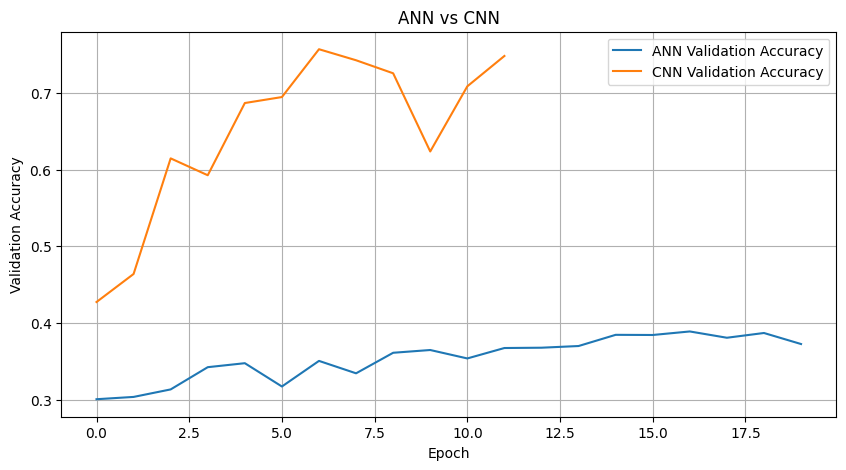

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN Validation Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('ANN vs CNN')
plt.legend()
plt.grid(True)
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(
        32,
        3,
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation='relu',
        padding='same'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# Train Augmented CNN

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 200s 275ms/step - accuracy: 0.3231 - loss: 1.9006 - val_accuracy: 0.4292 - val_loss: 1.5067
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 176s 239ms/step - accuracy: 0.4388 - loss: 1.5786 - val_accuracy: 0.4752 - val_loss: 1.4683
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 185s 262ms/step - accuracy: 0.4909 - loss: 1.4351 - val_accuracy: 0.5826 - val_loss: 1.1971
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 184s 261ms/step - accuracy: 0.5295 - loss: 1.3470 - val_accuracy: 0.6264 - val_loss: 1.1604
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 183s 260ms/step - accuracy: 0.5574 - loss: 1.2741 - val_accuracy: 0.5610 - val_loss: 1.2344


# Evaluate Augmented CNN

In [ ]:
aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.4252 - loss: 1.5190
Augmented CNN Accuracy: 0.4251999855041504


# Final Accuracy Comparison Plot

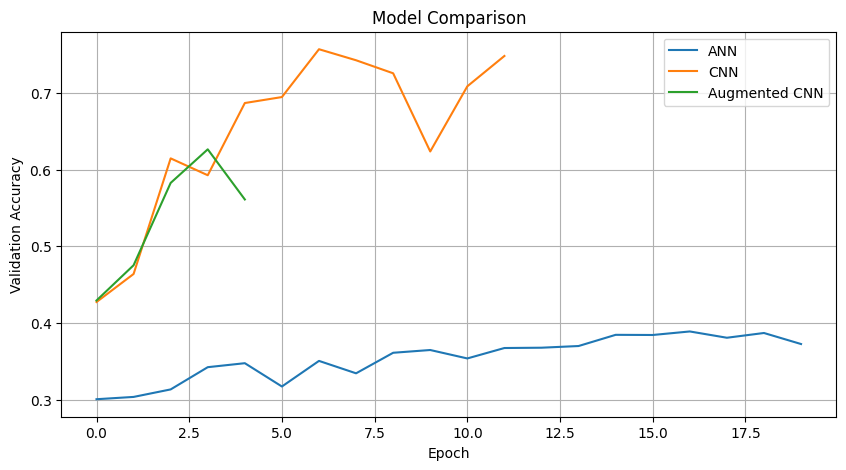

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN'
)

plt.plot(
    aug_history.history['val_accuracy'],
    label='Augmented CNN'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison')
plt.legend()
plt.grid(True)
plt.show()

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    'Model': ['ANN', 'CNN', 'Augmented CNN'],
    'Test Accuracy': [
        ann_acc,
        cnn_acc,
        aug_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.3958
1,CNN,0.7451
2,Augmented CNN,0.4252


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**